# Previsão de Sobrevivência no Titanic

Este projeto tem como objetivo prever quais os passageiros que sobreviveram ao naufrágio do Titanic, utilizando algoritmos de *Machine Learning* para classificação binária. 

O fluxo de trabalho inclui:
1. **Análise Exploratória de Dados (EDA):** Compreender as distribuições e relações entre as variáveis.
2. **Engenharia de Variáveis (Feature Engineering):** Criar novas características (como o tamanho da família e o título da pessoa) para enriquecer o modelo.
3. **Modelação e Avaliação:** Treinar e comparar múltiplos algoritmos para identificar o mais eficaz.

In [1]:
# Importação das bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

# Configuração visual
sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

## 1. Carregamento e Exploração de Dados (EDA)
Vamos começar por carregar os dados e visualizar a sua estrutura, bem como a proporção de sobreviventes.

In [19]:
# Carregar o dataset
df = pd.read_csv('titanic.csv')

display(df.head())

print(f"O dataset contém {df.shape[0]} linhas e {df.shape[1]} colunas.\n")
print("Valores nulos por coluna:")
print(df.isnull().sum())

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


O dataset contém 891 linhas e 12 colunas.

Valores nulos por coluna:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


Como podemos observar, existem valores nulos nas colunas `Age` (Idade), `Cabin` (Cabine) e `Embarked` (Porto de Embarque). Iremos tratar disso na fase de limpeza.
Antes disso, vamos visualizar como algumas variáveis influenciaram a taxa de sobrevivência.

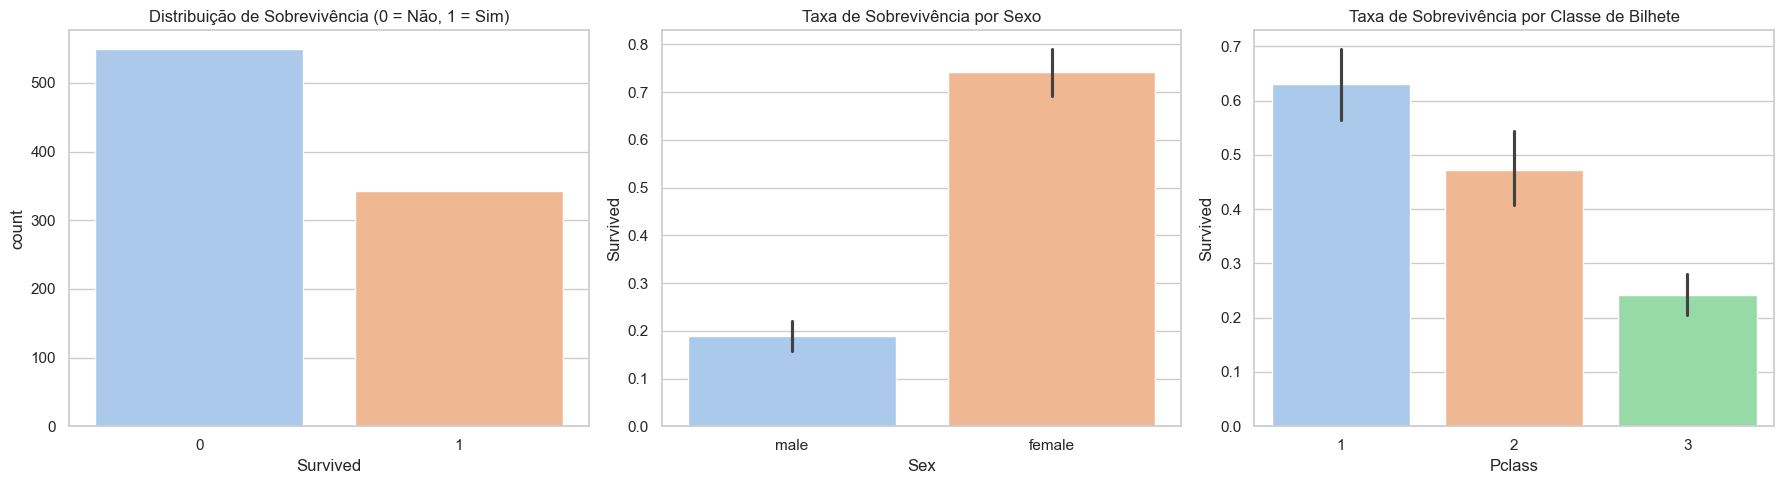

In [20]:
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# Sobrevivência Geral
sns.countplot(data=df, x='Survived', ax=axs[0], palette='pastel')
axs[0].set_title('Distribuição de Sobrevivência (0 = Não, 1 = Sim)')

# Sobrevivência por Sexo
sns.barplot(data=df, x='Sex', y='Survived', ax=axs[1], palette='pastel')
axs[1].set_title('Taxa de Sobrevivência por Sexo')

# Sobrevivência por Classe (Pclass)
sns.barplot(data=df, x='Pclass', y='Survived', ax=axs[2], palette='pastel')
axs[2].set_title('Taxa de Sobrevivência por Classe de Bilhete')

plt.tight_layout()
plt.show()

*Insights da EDA:*
* As mulheres tiveram uma taxa de sobrevivência drasticamente superior à dos homens.
* Passageiros da 1ª classe tiveram muito mais probabilidade de sobreviver do que os da 3ª classe.

## 2. Limpeza de Dados e Engenharia de Variáveis (*Feature Engineering*)
Para melhorar a performance do modelo, vamos extrair informações ocultas, como o título de cada pessoa (Sr., Sra., etc.) a partir do nome, e criar uma variável para o tamanho da família.

In [ ]:
# Análise de Idade: Mediana por Classe e Sexo"
print("Mediana da idade por classe e sexo:")
print(df.groupby(["Pclass", "Sex"])["Age"].median())
print(f"\nValores de idade em falta: {df['Age'].isnull().sum()}")


# 1. Tratar a Idade (Age): Preencher nulos com a mediana agrupada por Classe e Sexo
df['Age'] = df.groupby(['Pclass', 'Sex'])['Age'].transform(lambda x: x.fillna(x.median()))

# 2. Tratar Embarque: Preencher os 2 nulos com o valor mais comum (Moda)
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# 3. Engenharia de Variáveis: Extrair o Título do Nome
df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
# Agrupar títulos raros
titulos_raros = ['Lady', 'Countess','Capt', 'Col', 'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona']
df['Title'] = df['Title'].replace(titulos_raros, 'Rare')
df['Title'] = df['Title'].replace(['Mlle', 'Ms'], 'Miss')
df['Title'] = df['Title'].replace('Mme', 'Mrs')

# 4. Engenharia de Variáveis: Tamanho da Família
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = 1 # Inicializar como sozinho
df.loc[df['FamilySize'] > 1, 'IsAlone'] = 0 # Se tamanho > 1, não está sozinho

# 5. Variável Cabine: Como tem muitos nulos, vamos apenas criar uma flag "Tem_Cabine"
df['HasCabin'] = df['Cabin'].apply(lambda x: 0 if type(x) == float else 1)

# 6. Descartar colunas que já não precisamos
colunas_a_remover = ['PassengerId', 'Name', 'Ticket', 'Cabin']
df = df.drop(columns=colunas_a_remover)

# Confirm no missing values remain
print("Missing values after cleaning:")
print(df.isnull().sum())
print(f"\nTotal missing: {df.isnull().sum().sum()}")


display(df.head())

Mediana da idade por classe e sexo:
Pclass  Sex   
1       female    35.0
        male      40.0
2       female    28.0
        male      30.0
3       female    21.5
        male      25.0
Name: Age, dtype: float64

Valores de idade em falta: 177
Missing values after cleaning:
Survived      0
Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Embarked      0
Title         0
FamilySize    0
IsAlone       0
HasCabin      0
dtype: int64

Total missing: 0


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title,FamilySize,IsAlone,HasCabin
0,0,3,male,22.0,1,0,7.2500,S,Mr,2,0,0
1,1,1,female,38.0,1,0,71.2833,C,Mrs,2,0,1
2,1,3,female,26.0,0,0,7.9250,S,Miss,1,1,0
3,1,1,female,35.0,1,0,53.1000,S,Mrs,2,0,1
4,0,3,male,35.0,0,0,8.0500,S,Mr,1,1,0


## 3. Pré-processamento (*One-Hot Encoding* e Scaling)
Os algoritmos matemáticos precisam que o texto seja convertido em números. Vamos transformar o Sexo, Porto de Embarque e o Título em variáveis binárias (Dummies).

In [ ]:
# Converter variáveis categóricas (One-Hot Encoding)
df = pd.get_dummies(df, columns=['Sex', 'Embarked', 'Title'], drop_first=True)

# Converter eventuais valores booleanos (True/False) para 1 e 0
colunas_booleanas = df.select_dtypes(include=['bool']).columns
df[colunas_booleanas] = df[colunas_booleanas].astype(int)

# Separar variáveis independentes (X) do alvo (y)
X = df.drop('Survived', axis=1)
y = df['Survived']

# Divisão de Treino e Teste (80% / 20%)
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling dos dados (Standardization)
sc = StandardScaler()
X_treino_scaled = sc.fit_transform(X_treino)
X_teste_scaled = sc.transform(X_teste)

## 4. Modelação e Comparação de Múltiplos Algoritmos
Por ser um problema de Classificação Binária, vamos testar uma vasta gama de algoritmos para ver qual se adapta melhor aos nossos dados. As métricas de avaliação serão:
* **Accuracy:** Percentagem de acertos totais.
* **Precision & Recall:** Importantes para perceber como o modelo lida com Falsos Positivos e Falsos Negativos.
* **F1-Score:** A média harmónica entre Precision e Recall.

In [ ]:
# Importar modelos adicionais
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

# Dicionário expandido com os modelos a testar
modelos = {
    "Regressão Logística": LogisticRegression(random_state=42),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42), # <-- Adicionar o modelo
    "SVM": SVC(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

resultados = []

# Ciclo para treinar e avaliar todos os modelos base
for nome, modelo in modelos.items():
    modelo.fit(X_treino_scaled, y_treino)
    previsoes = modelo.predict(X_teste_scaled)
    
    acc = accuracy_score(y_teste, previsoes)
    prec = precision_score(y_teste, previsoes)
    rec = recall_score(y_teste, previsoes)
    f1 = f1_score(y_teste, previsoes)
    
    resultados.append({"Modelo": nome, "Accuracy": acc, "Precision": prec, "Recall": rec, "F1-Score": f1})

# Visualizar a tabela de resultados ordenada por Accuracy
df_resultados = pd.DataFrame(resultados).sort_values(by="Accuracy", ascending=False)
display(df_resultados.style.background_gradient(cmap='Greens'))

,Modelo,Accuracy,Precision,Recall,F1-Score
0,Regressão Logística,0.826816,0.794521,0.783784,0.789116
4,Random Forest,0.826816,0.786667,0.797297,0.791946
3,SVM,0.821229,0.800000,0.756757,0.777778
5,Gradient Boosting,0.815642,0.815385,0.716216,0.762590
1,KNN,0.815642,0.780822,0.770270,0.775510
2,Decision Tree,0.810056,0.770270,0.770270,0.770270
6,XGBoost,0.810056,0.777778,0.756757,0.767123


## 5. Otimização de Hiperparâmetros (GridSearchCV)
Geralmente, modelos baseados em árvores (como o *Random Forest* ou *Gradient Boosting*) têm um excelente desempenho. Para extrair o máximo potencial do modelo, vamos utilizar o **GridSearchCV**. 

Esta técnica testa automaticamente várias combinações de parâmetros (como a profundidade das árvores ou o número de estimadores) usando *Cross-Validation*, para encontrar a configuração "perfeita".

In [ ]:
from sklearn.model_selection import GridSearchCV

print("A iniciar o GridSearchCV para o Random Forest... (Pode demorar uns segundos)")

# 1. Definir o modelo base que queremos otimizar
rf_base = RandomForestClassifier(random_state=42)

# 2. Definir a "grelha" de parâmetros a testar
parametros_grid = {
    'n_estimators': [100, 200, 300],        # Número de árvores
    'max_depth': [None, 5, 10, 15],         # Profundidade máxima de cada árvore
    'min_samples_split': [2, 5, 10],        # Número mínimo de amostras para dividir um nó
    'min_samples_leaf': [1, 2, 4]           # Número mínimo de amostras numa folha final
}

# 3. Configurar o GridSearchCV (cv=4 significa 4-Fold Cross Validation)
grid_search = GridSearchCV(estimator=rf_base, param_grid=parametros_grid, 
                           cv=4, n_jobs=-1, scoring='accuracy')

# 4. Treinar o GridSearch
grid_search.fit(X_treino_scaled, y_treino)

print("Pesquisa concluída!")
print(f"Melhores parâmetros encontrados: {grid_search.best_params_}")

# 5. Guardar o modelo
modelo_otimizado = grid_search.best_estimator_

# Avaliar o modelo otimizado nos dados de teste
previsoes_otimizadas = modelo_otimizado.predict(X_teste_scaled)
acc_otimizada = accuracy_score(y_teste, previsoes_otimizadas)

print(f"Accuracy do modelo otimizado nos dados de teste: {acc_otimizada:.4f}")

A iniciar o GridSearchCV para o Random Forest... (Pode demorar uns segundos)
Pesquisa concluída!
Melhores parâmetros encontrados: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 200}
Accuracy do modelo otimizado nos dados de teste: 0.8156


### Análise da Otimização (GridSearchCV)
Curiosamente, a otimização de hiperparâmetros resultou numa ligeira queda na métrica de *Accuracy* no nosso conjunto de teste (comparativamente ao modelo *Random Forest* com configurações padrão). 

**Porquê que isto acontece?**
1. O modelo base do `scikit-learn` cresce as árvores sem restrições (`max_depth=None`), o que pode levar a um ligeiro *overfitting* que, por acaso, se adaptou bem a este conjunto de teste específico.
2. O `GridSearchCV` otimizou os parâmetros com base numa validação cruzada de 4 dobras (*4-Fold CV*) nos dados de treino. O modelo otimizado é mais regularizado, conservador e menos propenso a falhar em dados do mundo real, mesmo que tenha perdido uma fração de precisão neste teste isolado.

Isto demonstra a importância de não avaliar modelos baseando-nos apenas num único conjunto de teste, mas sim na sua estabilidade (Cross-Validation). Para o modelo final, vamos avançar com o Random Forest Classifier que obteve o melhor equilíbrio geral.

## 6. Avaliação Final do Modelo Vencedor (Random Forest)
Tendo escolhido o **Random Forest** base como o nosso modelo final, vamos agora visualizar o seu desempenho detalhado através da Matriz de Confusão (para percebermos a proporção de falsos positivos e falsos negativos) e analisar quais foram as características dos passageiros que mais ditaram a sua sobrevivência.

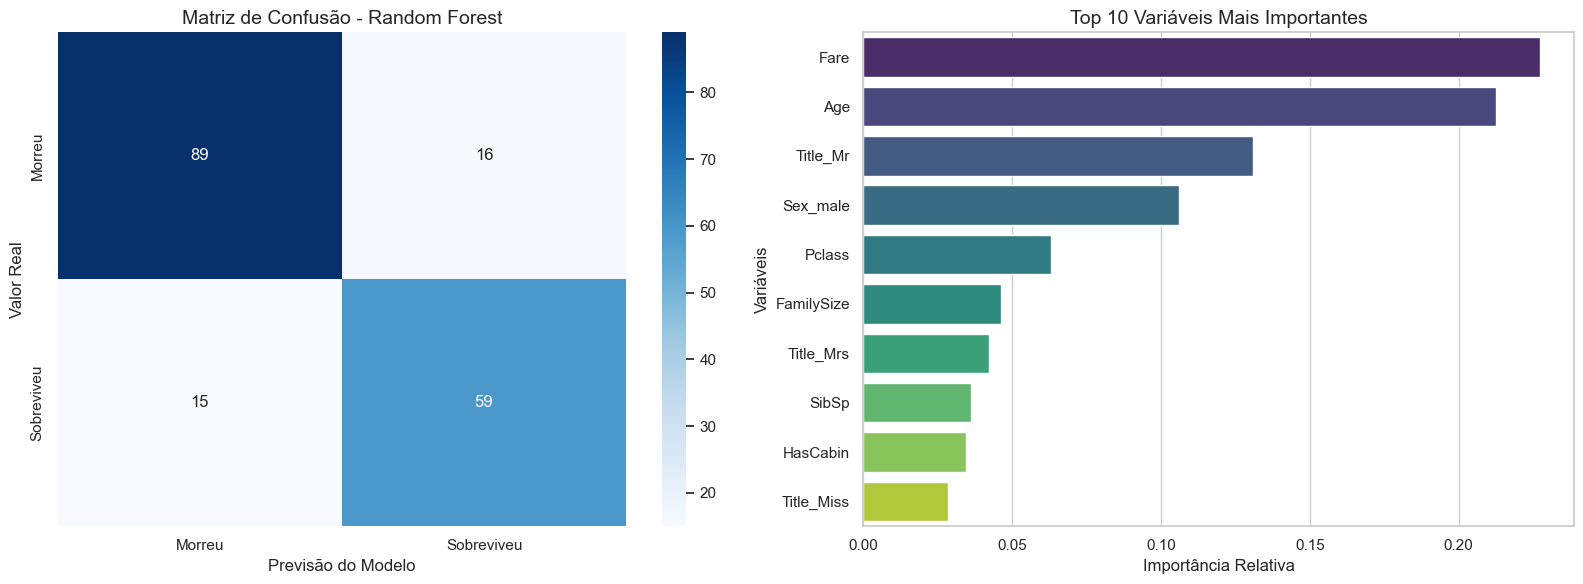

Fim do projeto. O modelo está treinado e avaliado com sucesso!


In [ ]:
# 1. Re-treinar o modelo vencedor original (Random Forest) para garantir a extração correta
modelo_final = RandomForestClassifier(n_estimators=100, random_state=42)
modelo_final.fit(X_treino_scaled, y_treino)
previsoes_finais = modelo_final.predict(X_teste_scaled)

# 2. Calcular a Matriz de Confusão
cm = confusion_matrix(y_teste, previsoes_finais)

# Criar a área de plotagem (1 linha, 2 colunas)
fig, axs = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Matriz de Confusão
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axs[0],
            xticklabels=['Morreu', 'Sobreviveu'], yticklabels=['Morreu', 'Sobreviveu'])
axs[0].set_title('Matriz de Confusão - Random Forest', fontsize=14)
axs[0].set_ylabel('Valor Real', fontsize=12)
axs[0].set_xlabel('Previsão do Modelo', fontsize=12)

# 3. Extrair a Importância das Variáveis
importancias = pd.Series(modelo_final.feature_importances_, index=X.columns).sort_values(ascending=False)

# Gráfico 2: Importância das Variáveis
sns.barplot(x=importancias.values[:10], y=importancias.index[:10], hue=importancias.index[:10], palette='viridis', ax=axs[1], legend=False)
axs[1].set_title('Top 10 Variáveis Mais Importantes', fontsize=14)
axs[1].set_xlabel('Importância Relativa', fontsize=12)
axs[1].set_ylabel('Variáveis', fontsize=12)

plt.tight_layout()
plt.show()

print("Fim do projeto. O modelo está treinado e avaliado com sucesso!")